# Using WCRR in STIR with PD3O

In this notebook we are using WCRR in a variational regularisation setting with the PD3O algorithm.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

import sirf.STIR as pet
from cil.optimisation.functions import Function
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils.parametrize as P
import time  

# define the directory with input files for this notebook
examples_data_path_PET = '/opt/SIRF-SuperBuild/INSTALL/share/SIRF-3.9/data/examples/PET'
data_path = os.path.join(examples_data_path_PET, 'thorax_single_slice')


In [2]:
# set-up redirection of STIR messages to files
msg_red = pet.MessageRedirector('info.txt', 'warnings.txt', 'errors.txt')

In [3]:
def make_cylindrical_FOV(image):
    """truncate to cylindrical FOV"""
    filter = pet.TruncateToCylinderProcessor()
    filter.apply(image)

In [41]:
#%% Read in images
ground_truth = pet.ImageData(os.path.join(data_path, 'emission.hv'))*0.5
attn_image = pet.ImageData(os.path.join(data_path, 'attenuation.hv'))
template = pet.AcquisitionData(os.path.join(data_path, 'template_sinogram.hs'))

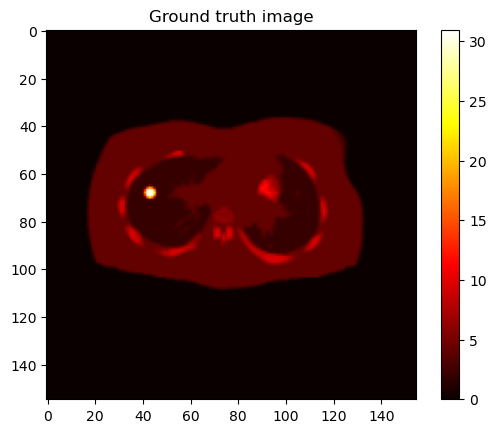

In [42]:
plt.figure()
plt.imshow(ground_truth.as_array()[0], cmap="hot")
plt.title("Ground truth image")
plt.colorbar()
plt.show()

In [43]:
# create attenuation
acq_model_for_attn = pet.AcquisitionModelUsingRayTracingMatrix()
asm_attn = pet.AcquisitionSensitivityModel(attn_image, acq_model_for_attn)
asm_attn.set_up(template)
attn_factors = asm_attn.forward(template.get_uniform_copy(1))
asm_attn = pet.AcquisitionSensitivityModel(attn_factors)

In [44]:
# create acquisition model
acq_model = pet.AcquisitionModelUsingRayTracingMatrix()
# we will increase the number of rays used for every Line-of-Response (LOR) as an example
# (it is not required for the exercise of course)
#acq_model.set_num_tangential_LORs(5)
acq_model.set_acquisition_sensitivity(asm_attn)
# set-up
acq_model.set_up(template,ground_truth)

In [45]:
#%% simulate some data using forward projection
clean_data = acq_model.forward(ground_truth)
acquired_data = clean_data.clone()
acquired_data.fill(np.random.poisson(clean_data.as_array()).astype(np.float32))
#acquired_data = clean_data

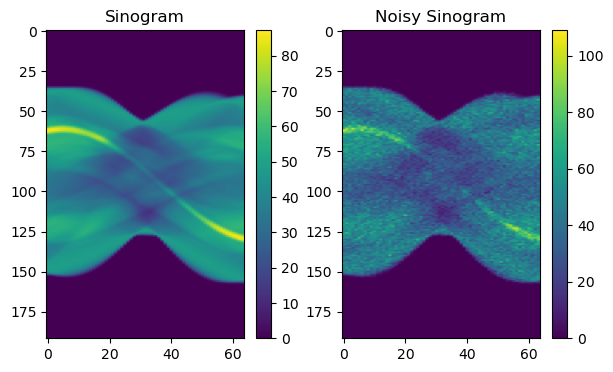

In [46]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7,4))

im = ax1.imshow(clean_data.as_array()[0,0].T, aspect='auto')
fig.colorbar(im, ax=ax1)
ax1.set_title("Sinogram")

im = ax2.imshow(acquired_data.as_array()[0,0].T, aspect='auto')
fig.colorbar(im, ax=ax2)
ax2.set_title("Noisy Sinogram")
plt.show()

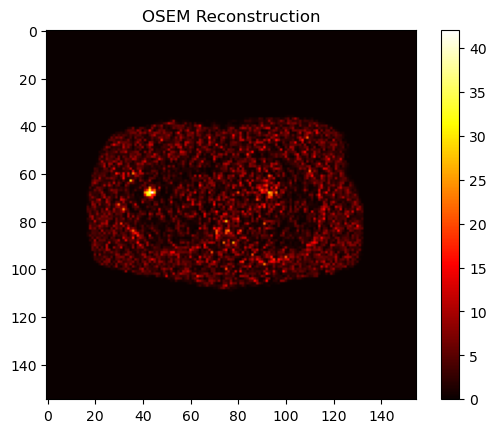

In [47]:
# --- OSEM reconstruction ---

# OSEM setup
num_subsets = 4
num_subiterations = 100

osem_obj_fun = pet.make_Poisson_loglikelihood(acquired_data)
osem_obj_fun.set_acquisition_model(acq_model)

osem = pet.OSMAPOSLReconstructor()
osem.set_objective_function(osem_obj_fun)
osem.set_num_subsets(num_subsets)
osem.set_num_subiterations(num_subiterations)

osem_initial = ground_truth.get_uniform_copy(ground_truth.max() * 0.15)
make_cylindrical_FOV(osem_initial)

osem.set_current_estimate(osem_initial)
osem.set_up(osem_initial)
osem.process()

osem_recon = osem.get_output()

plt.figure()
plt.imshow(osem_recon.as_array()[0],  cmap="hot")
plt.colorbar()
plt.title("OSEM Reconstruction")
plt.show()


In [48]:
obj_fun = pet.make_Poisson_loglikelihood(acquired_data)
obj_fun.set_acquisition_model(acq_model)


In [49]:

class ZeroMean(nn.Module):
    """Enforcing zero mean on the filters improves performances"""

    def forward(self, x):
        return x - torch.mean(x, dim=(1, 2, 3), keepdim=True)


class WCRR(nn.Module):
    def __init__(
        self,
        sigma,  # scaling constant (we set it always to 0.1)
        weak_convexity,  # set to 0.0 for CRR and to 1.0 for WCRR
        tanh=False,  # whether to use tanh instead of smoothed l1 as potential
        nb_channels=[1, 4, 8, 64],  # number channels in the multiconv
        filter_sizes=[5, 5, 5],  # filter sizes of the convolution
        device="cuda" if torch.cuda.is_available() else "cpu",  # device
        pretrained=None,  # if a str is given here, the weights from the corresponding path will be loaded
    ):
        super().__init__()

        self.nb_filters = nb_channels[-1]
        self.filter_size = sum(filter_sizes) - len(filter_sizes) + 1
        self.filters = nn.Sequential(
            *[
                nn.Conv2d(
                    nb_channels[i],
                    nb_channels[i + 1],
                    filter_sizes[i],
                    padding=filter_sizes[i] // 2,
                    bias=False,
                )
                for i in range(len(filter_sizes))
            ]
        )
        P.register_parametrization(self.filters[0], "weight", ZeroMean())

        # only works for 1 input channel
        #self.dirac = torch.zeros(
        #    1, 1, 2 * self.filter_size - 1, 2 * self.filter_size - 1
        #)
        
        self.dirac = torch.zeros(
            nb_channels[0], nb_channels[0], 2 * self.filter_size - 1, 2 * self.filter_size - 1
        )
        self.dirac[:, :, self.filter_size - 1, self.filter_size - 1] = 1.0

        self.scaling = nn.Parameter(
            torch.log(torch.tensor(2.0) / sigma) * torch.ones(1, self.nb_filters, 1, 1)
        )
        self.beta = nn.Parameter(torch.tensor(4.0))
        self.weak_cvx = weak_convexity
        self.tanh = tanh

        if pretrained is not None:
            self.load_state_dict(torch.load(pretrained, map_location=device))

    def smooth_l1(self, x):
        if self.tanh:
            x_abs = torch.abs(x)
            return torch.log((torch.exp(x - x_abs) + torch.exp(-x - x_abs)) / 2) + x_abs
        return torch.clip(x**2, 0.0, 1.0) / 2 + torch.clip(torch.abs(x), 1.0) - 1.0

    def grad_smooth_l1(self, x):
        if self.tanh:
            return torch.tanh(x)
        else:
            return torch.clip(x, -1.0, 1.0)

    def get_conv_lip(self):
        impulse = self.filters(self.dirac)
        for filt in reversed(self.filters):
            impulse = F.conv_transpose2d(impulse, filt.weight, padding=filt.padding)
        return torch.fft.fft2(impulse, s=[256, 256]).abs().max()

    def conv(self, x):
        x = x / torch.sqrt(self.get_conv_lip())
        return self.filters(x)

    def conv_transpose(self, x):
        x = x / torch.sqrt(self.get_conv_lip())
        for filt in reversed(self.filters):
            x = F.conv_transpose2d(x, filt.weight, padding=filt.padding)
        return x

    def grad(self, x, get_energy=False):
        grad = self.conv(x)
        grad = grad * torch.exp(self.scaling)
        if get_energy:
            reg = (
                self.smooth_l1(torch.exp(self.beta) * grad) * torch.exp(-self.beta)
                - self.smooth_l1(grad) * self.weak_cvx
            )
            reg = reg * torch.exp(-2 * self.scaling)
            reg = reg.sum(dim=(1, 2, 3))
        grad = (
            self.grad_smooth_l1(torch.exp(self.beta) * grad)
            - self.grad_smooth_l1(grad) * self.weak_cvx
        )
        grad = grad * torch.exp(-self.scaling)
        grad = self.conv_transpose(grad)
        if get_energy:
            return reg, grad
        return grad

    def g(self, x):
        reg = self.conv(x)
        reg = reg * torch.exp(self.scaling)
        reg = (
            self.smooth_l1(torch.exp(self.beta) * reg) * torch.exp(-self.beta)
            - self.smooth_l1(reg) * self.weak_cvx
        )
        reg = reg * torch.exp(-2 * self.scaling)
        reg = reg.sum(dim=(1, 2, 3))
        return reg

    def _apply(self, fn):
        self.dirac = fn(self.dirac)
        return super()._apply(fn)



class WCRRCIL(Function):
    def __init__(self, lamb=1.0, scale=1.0):
        # R_tilde(x)= self.lamb/self.scale**2 R(self.scale * x)
        self.scale = scale 
        self.lamb = lamb
        # Torch WCRR model
        self.model = WCRR(
            sigma=0.1,
            weak_convexity=0.0,
            nb_channels=[1, 4, 8, 64],
            device="cpu"
        )
        weights = torch.load("/home/jovyan/work/SIRF-Exercises/notebooks/PET/WCRR_bilevel_JFB_for_CT.pt")
        new_weights = {}
        model_dict = self.model.state_dict()
        for k, v in weights.items():
            if k.startswith("regularizer."):
                new_k = k.replace("regularizer.", "")
                if new_k in model_dict:
                    new_weights[new_k] = v
        self.model.load_state_dict(new_weights, strict=False)
        self.device="cpu"

    def _image_to_tensor(self, image):
        """Convert STIR ImageData -> torch tensor"""
        arr = image.as_array()
        x = torch.from_numpy(arr).float().to(self.device)

        # STIR images are (z,y,x). Network expects (B,C,H,W)
        x = x.unsqueeze(0)
        
        return x

    def _tensor_to_image(self, tensor, ref_image):
        """Convert torch tensor -> STIR ImageData"""
        # needs some ref_image 
        arr = tensor.detach().cpu().numpy()

        out = ref_image.get_uniform_copy(0)
        out.fill(arr)
        return out

    def __call__(self, image):
        """Return prior energy"""
        x = self._image_to_tensor(image)

        with torch.no_grad():
            reg = self.model.g(self.scale * x) / self.scale**2

        return self.lamb * float(reg.item())

    def gradient(self, image, out=None):
        """Return gradient as STIR ImageData"""
        start_time = time.time()
        
        x = self._image_to_tensor(image)
        x.requires_grad_(True)

        with torch.enable_grad():
            grad = self.model.grad(self.scale * x)[0]

        if out is None:
            out = image.get_uniform_copy(0)

        grad_img = self._tensor_to_image(grad, image)
        # restrict gradient to FOV
        make_cylindrical_FOV(grad_img)
        out.fill(self.lamb * grad_img.as_array()/self.scale)
        end_time = time.time()
        #print("gradient call of WCRR: ", end_time - start_time) 
        # this is about 0.2s 
        return out



In [52]:
from cil.optimisation.algorithms import PD3O
from cil.optimisation.functions import KullbackLeibler, IndicatorBox, BlockFunction, Function
from cil.optimisation.operators import BlockOperator
K = acq_model

f = KullbackLeibler(b=acquired_data, eta=(acquired_data * 0 + 1e-5))


#delta = 0.05 #gamma*ones_data/acq_model.get_linear_acquisition_model().forward(ones_image)
#gamma = 1/gamma*ones_image/acq_model.backward(ones_data)
#gamma = 1./(delta*70**2)
gamma = 0.5 
delta = 1./(gamma*K.norm()**2)

g = IndicatorBox(lower=0)
        
def do_nothing(self):
    return 0.
setattr(PD3O, 'update_objective', do_nothing)

wcrr_cil = WCRRCIL(lamb=2.0, scale=0.5)

# Setup and run PDHG
initial_image = ground_truth.get_uniform_copy(ground_truth.max() / 6)
make_cylindrical_FOV(initial_image)
        
# gamma: primal step size 
# delta: dual step size 
pd3o = PD3O(f=wcrr_cil, g=g, h=f, operator=K, delta=delta, gamma=gamma, 
                    update_objective_interval = 4, initial=initial_image)
                    #check_convergence=False)
        
pd3o.run(100)

  0%|          | 0/100 [00:00<?, ?it/s]

 term added
applying unnormalisation...ok
backprojecting...ok
no additive term added
applying unnormalisation...ok
no background term added
applying unnormalisation...ok
backprojecting...ok
no additive term added
applying unnormalisation...ok
no background term added
applying unnormalisation...ok
backprojecting...ok
no additive term added
applying unnormalisation...ok
no background term added
applying unnormalisation...ok
backprojecting...ok
no additive term added
applying unnormalisation...ok
no background term added
applying unnormalisation...ok
backprojecting...ok
no additive term added
applying unnormalisation...ok
no background term added
applying unnormalisation...ok
backprojecting...ok
no additive term added
applying unnormalisation...ok
no background term added
applying unnormalisation...ok
backprojecting...ok
no additive term added
applying unnormalisation...ok
no background term added
applying unnormalisation...ok
backprojecting...ok
no additive term added
applying unnormalis

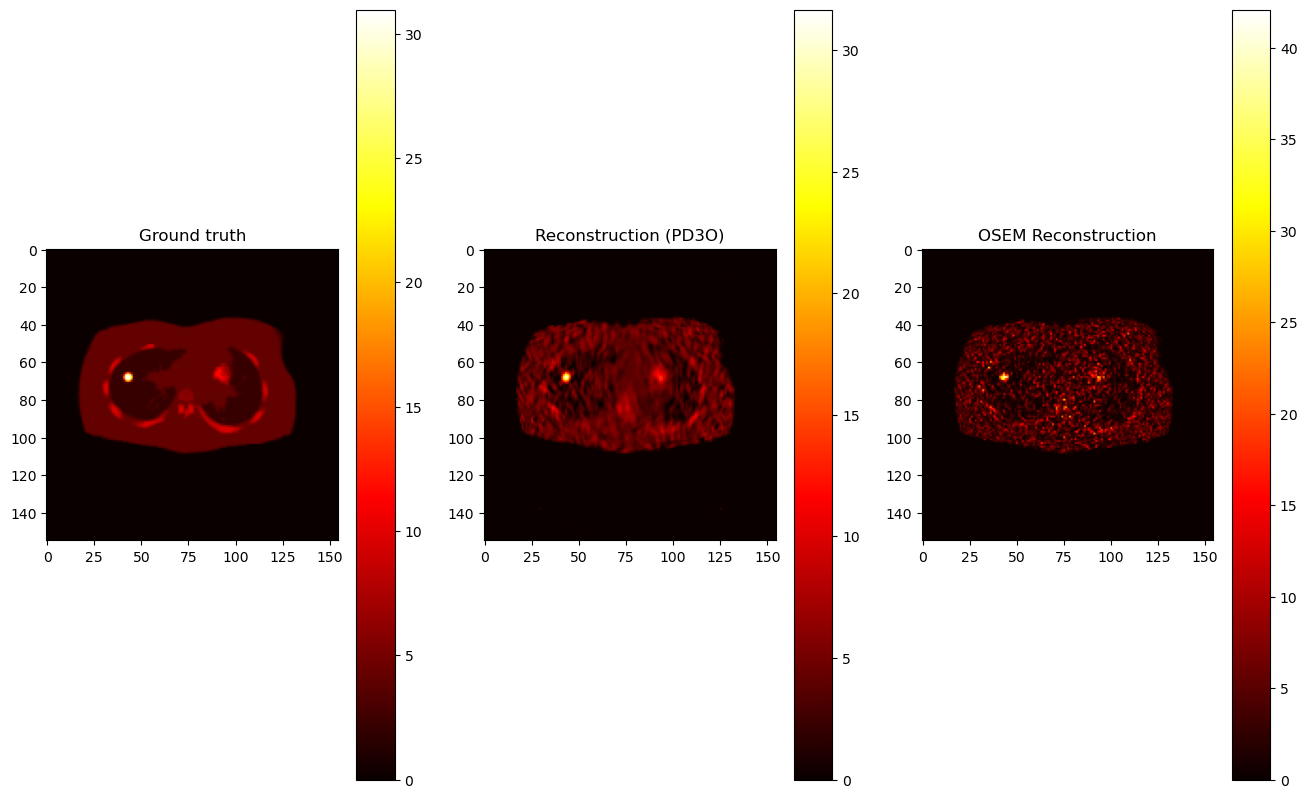

In [51]:
fig, axes = plt.subplots(1,3, figsize=(16,10))

im = axes[0].imshow(ground_truth.as_array()[0], vmin=0,  cmap="hot")
fig.colorbar(im, ax=axes[0])
axes[0].set_title("Ground truth")

im = axes[1].imshow(pd3o.solution.as_array()[0], vmin=0, cmap="hot")
fig.colorbar(im, ax=axes[1])
axes[1].set_title("Reconstruction (PD3O)")

im = axes[2].imshow(osem_recon.as_array()[0], vmin=0, cmap="hot")
fig.colorbar(im, ax=axes[2])
axes[2].set_title("OSEM Reconstruction")

plt.show()

In [43]:
sol = pd3o.solution.clone()

In [48]:
sol_null = pd3o.solution.clone()

In [ ]:
#%% perform GA iterations
# executing this cell might take a while
for i in range(1, num_subiters+1):  
    # obtain gradient for subset 0
    # with current settings, this means we will only use the data of that subset
    # (gradient ascent with subsets is too complicated for this demo)
    grad = obj_fun.gradient(current_image, 0)
    grad_array = grad.as_array()

    # compute step-size as relative to current image-norm
    step_size = tau * norm(idata) / norm(grad_array)

    # perform gradient ascent step and truncate to positive values
    idata = make_positive(idata + step_size*grad_array)
    current_image.fill(idata)

    # compute objective function value for plotting, and write some diagnostics
    obj_fun_value = obj_fun.value(current_image)
    GA_objective_function_values.append(obj_fun_value)
    all_images[i,:,:,:] = idata;

In [ ]:
#%% Plot objective function values
plt.figure()
#plt.hold('on')
plt.title('Objective function value vs subiterations')
plt.plot(GA_objective_function_values,'b')
plt.plot(osem_objective_function_values,'r')
plt.legend(('gradient ascent', 'OSEM'),loc='lower right');

In [ ]:
#%% compare GA and OSEM images
plot_progress([all_images, all_osem_images], ['GA' ,'OSEM'],[2,4,8,16,32])

The above implementation used a fixed (relative) step-size. Experiment with different values for `tau` and see how that influences convergence.

Steepest gradient ascent will include a line search to estimate the step size. There is a demo
in the SIRF code on this. You can [find the code here as well](https://github.com/SyneRBI/SIRF/blob/master/examples/Python/PET/steepest_ascent.py). You could implement this here.

# Exercise: repeat this analysis with noisy data

In the above simulation, the `acquired_data` was "perfect", i.e. it was the output of the same acquisition model as used for the reconstruction *and* there was no noise in the data. In real life, you will never be so lucky!

Of course, performance of a reconstruction algorithm needs to be investigated in more realistic scenarios. We suggest that you use a Poisson realisation of the data, and then repeat the above cells.

We can use the `numpy.random.poisson` function to create a noisy realisation of the simulated data. Of course, we will need to convert the data to `numpy` first via `as_array()`.

One thing to watch out for is that Poisson statstics is (solely) determined by the mean (in contrast to the normal distribution, which has separate mean and standard deviation). Therefore, the "magnitude" of the simulated data will be very important to determine the noise level. The relevant formula for Poisson statistics is that
<center>variance = mean</center>

This exercise is set-up such that the mean of the simulated data is "reasonable" such that you will get some noise in the data, but not too much. Obviously, if you use other data, you will have to check what happens. You can simply rescale the `acquired_data` (up for less noise, down for more), which will then of course rescale the reconstructed images as well.

In [ ]:
#%% Generate a noisy realisation of the data

noisy_array=numpy.random.poisson(acquired_data.as_array()).astype('float64')
print(' Maximum counts in the data: %d' % noisy_array.max())
# stuff into a new AcquisitionData object
noisy_data = acquired_data.clone()
noisy_data.fill(noisy_array);

In [ ]:
#%% Display bitmaps of the middle sinogram
plt.figure(figsize=(9, 4))
plot_2d_image([1,2,1],acquired_data.as_array()[0,im_slice,:,:,],'original',[0,acquired_data.max()])
plot_2d_image([1,2,2],noisy_array[0,im_slice,:,:,],'noisy',[0,acquired_data.max()])
plt.tight_layout();

Now we set the objective function to use the noisy data instead. The rest of the cells above wouldn't need any changes (but do check!).

In [ ]:
obj_fun.set_acquisition_data(noisy_data)